LAB03 - Tarefa 03

vamos implementar um agrupamento hierárquico estimando a matriz de dissimilaridades. Para isso baixar o arquivo Lab03Tarefa03 disponibilizado na nossa Comunidade da disciplina no Moodle.

In [1]:
# Importa as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

In [2]:
# Gera os dados para o agrupamento
np.random.seed(123)
variables = ['X', 'Y', 'Z']
labels = ['ID_0','ID_1','ID_2','ID_3','ID_4']
X = np.random.random_sample([5,3])*10
df = pd.DataFrame(X, columns=variables, index=labels)
df

,X,Y,Z
ID_0,6.964692,2.861393,2.268515
ID_1,5.513148,7.194690,4.231065
ID_2,9.807642,6.848297,4.809319
ID_3,3.921175,3.431780,7.290497
ID_4,4.385722,0.596779,3.980443


In [3]:
# Encontra a matriz de dissimilaridade ou de distância
from scipy.spatial.distance import pdist, squareform
row_dist = pd.DataFrame(squareform(pdist(df, metric='euclidean')),columns=labels, index=labels)
row_dist

,ID_0,ID_1,ID_2,ID_3,ID_4
ID_0,0.000000,4.973534,5.516653,5.899885,3.835396
ID_1,4.973534,0.000000,4.347073,5.104311,6.698233
ID_2,5.516653,4.347073,0.000000,7.244262,8.316594
ID_3,5.899885,5.104311,7.244262,0.000000,4.382864
ID_4,3.835396,6.698233,8.316594,4.382864,0.000000


In [4]:
# Faz o agrupamento a partir da matriz de dissimilaridade
row_clusters = linkage(pdist(df, metric='euclidean'),method='ward')

In [5]:
# Faz o agrupamento a partir da base de dados
row_clusters = linkage(df,method='ward',metric='euclidean')

In [6]:
pd.DataFrame(row_clusters,columns=['row label 1','row label 2','distance','no. of items in clust.'],
             index=['cluster %d' %(i+1) for i in range(row_clusters.shape[0])])

,row label 1,row label 2,distance,no. of items in clust.
cluster 1,0.0,4.0,3.835396,2.0
cluster 2,1.0,2.0,4.347073,2.0
cluster 3,3.0,5.0,5.577515,3.0
cluster 4,6.0,7.0,8.332355,5.0


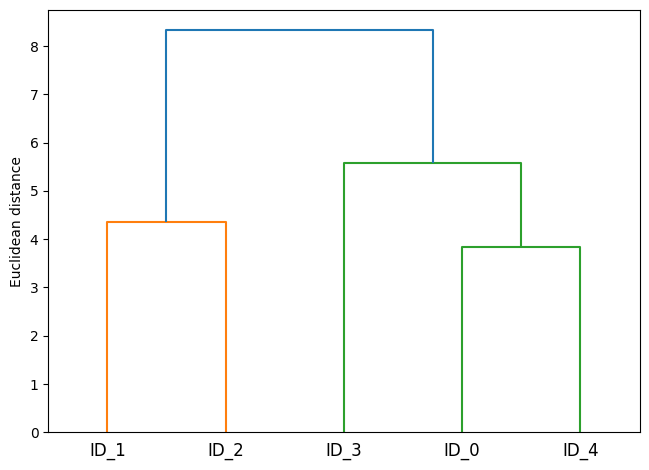

In [7]:
from scipy.cluster.hierarchy import dendrogram
row_dendr = dendrogram(row_clusters,labels=labels)
plt.tight_layout()
plt.ylabel('Euclidean distance')
plt.show()